# NBA Salaries and PER - Data Management for Data Science - Final Project

## Project Overview

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
#from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import mpl_toolkits
from sklearn import linear_model
%matplotlib inline
plt.style.use('ggplot')
import warnings
warnings.filterwarnings("ignore")

## Salaries Dataset

In [14]:
df = pd.read_csv('nba_2022_23_salary_stats_with_espn_hollinger_per.csv')

drop_df = df.drop(index = 0)

In [15]:
salaries_df = drop_df.filter(['Player Efficiency Rating (ESPN Hollinger 2022-23)', 'Salary'])
salaries_df.sort_values(by = ['Player Efficiency Rating (ESPN Hollinger 2022-23)'], ascending = False)

,Player Efficiency Rating (ESPN Hollinger 2022-23),Salary
459,65.6,"$58,493"
440,45.5,"$201,802"
27,31.4,"$33,616,770"
8,29.0,"$42,492,492"
14,27.8,"$37,980,720"
...,...,...
428,-3.5,"$500,000"
356,-5.0,"$1,709,300"
453,-6.8,"$113,114"
454,-12.6,"$105,522"


In [41]:
# -------------------------
# PER vs Salary Correlation and Evaluation
# -------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Clean column names
df.columns = df.columns.str.strip()

# Column names
salary_col = 'Salary'
per_col = 'Player Efficiency Rating (ESPN Hollinger 2022-23)'

# Clean salary column: "$47,345,760" -> 47345760
df[salary_col] = (
    df[salary_col]
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df[salary_col] = pd.to_numeric(df[salary_col], errors='coerce')

# Convert salary to millions
df['Salary_Millions'] = df[salary_col] / 1_000_000

# Convert PER to numeric
df[per_col] = pd.to_numeric(df[per_col], errors='coerce')

# Keep only rows with valid PER and salary
per_salary_df = df[[per_col, 'Salary_Millions']].dropna()

# -------------------------
# Correlation
# -------------------------

correlation = per_salary_df[per_col].corr(per_salary_df['Salary_Millions'])

print("PER and Salary Correlation")
print("---------------------------")
print(f"Correlation coefficient: {correlation:.3f}")

if correlation > 0.7:
    print("Interpretation: Strong positive correlation.")
elif correlation > 0.4:
    print("Interpretation: Moderate positive correlation.")
elif correlation > 0.2:
    print("Interpretation: Weak positive correlation.")
elif correlation > -0.2:
    print("Interpretation: Little to no linear correlation.")
else:
    print("Interpretation: Negative correlation.")

PER and Salary Correlation
---------------------------
Correlation coefficient: 0.412
Interpretation: Moderate positive correlation.


## Data Visualization

In [16]:
# Clean column names
salaries_df.columns = salaries_df.columns.str.strip()

# Convert Salary from "$47,345,760" to 47345760.0
salaries_df['Salary'] = (
    salaries_df['Salary']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

salaries_df['Salary'] = pd.to_numeric(salaries_df['Salary'], errors='coerce')

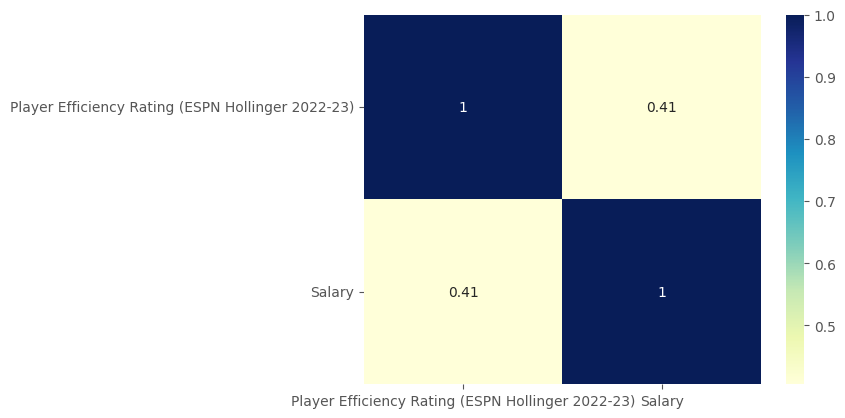

In [17]:
sns.heatmap(salaries_df.corr(), cmap = "YlGnBu", annot = True)
plt.show()

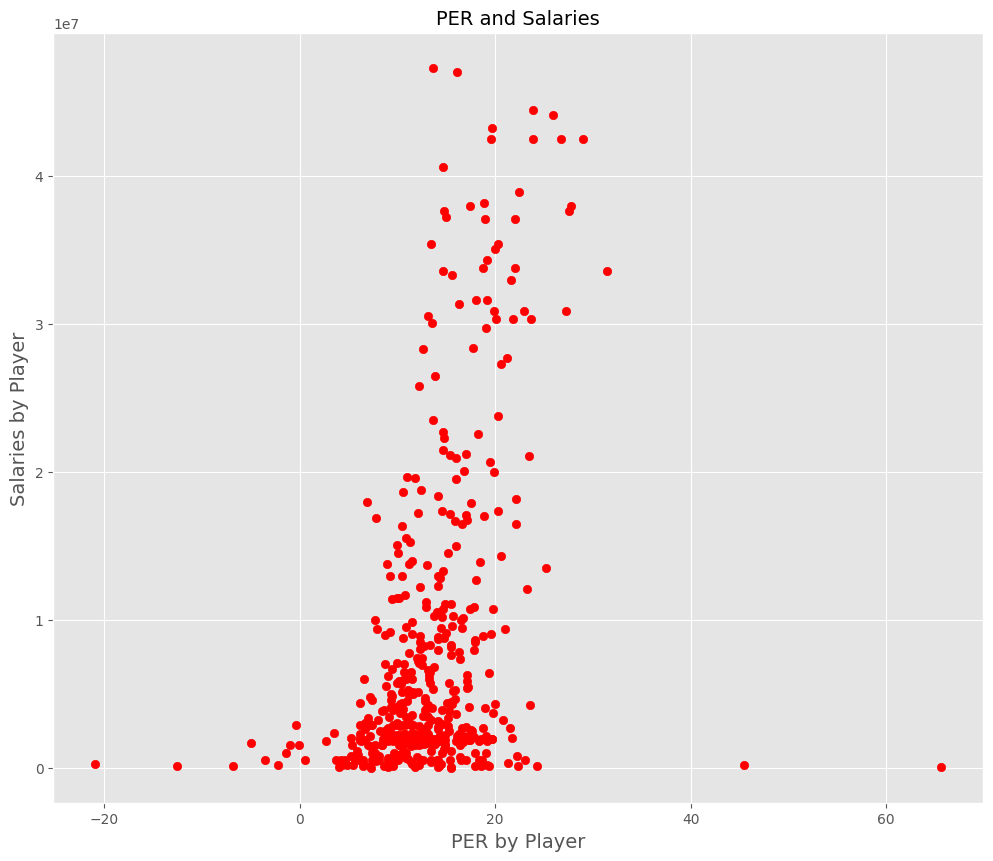

In [18]:
plt.figure(figsize = (12, 10))
plt.scatter(salaries_df['Player Efficiency Rating (ESPN Hollinger 2022-23)'], salaries_df['Salary'], color = 'red')
plt.title('PER and Salaries', fontsize = 14)
plt.xlabel('PER by Player', fontsize = 14)
plt.ylabel('Salaries by Player', fontsize = 14)
plt.grid(True)
plt.show()

In [19]:
real_df = salaries_df.drop('Salary', axis = "columns")
real_df

,Player Efficiency Rating (ESPN Hollinger 2022-23)
1,13.6
2,16.1
3,23.9
4,25.9
5,19.7
...,...
462,4.0
463,9.0
464,11.8
465,15.5


In [20]:
Salary = salaries_df['Salary']
Salary

1      47345760
2      47080179
3      44474988
4      44119845
5      43279250
         ...   
462       35096
463       32795
464       32171
465        5849
466        5849
Name: Salary, Length: 466, dtype: int64

## Linear Regression Model

In [21]:
lr = linear_model.LinearRegression()
lr.fit(real_df, Salary)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
# input x value to recieve y value
# x(PER) / y(Salaries)
lr.predict([[22.21]])

array([14495780.89284291])

In [23]:
y_predict = lr.predict(real_df)

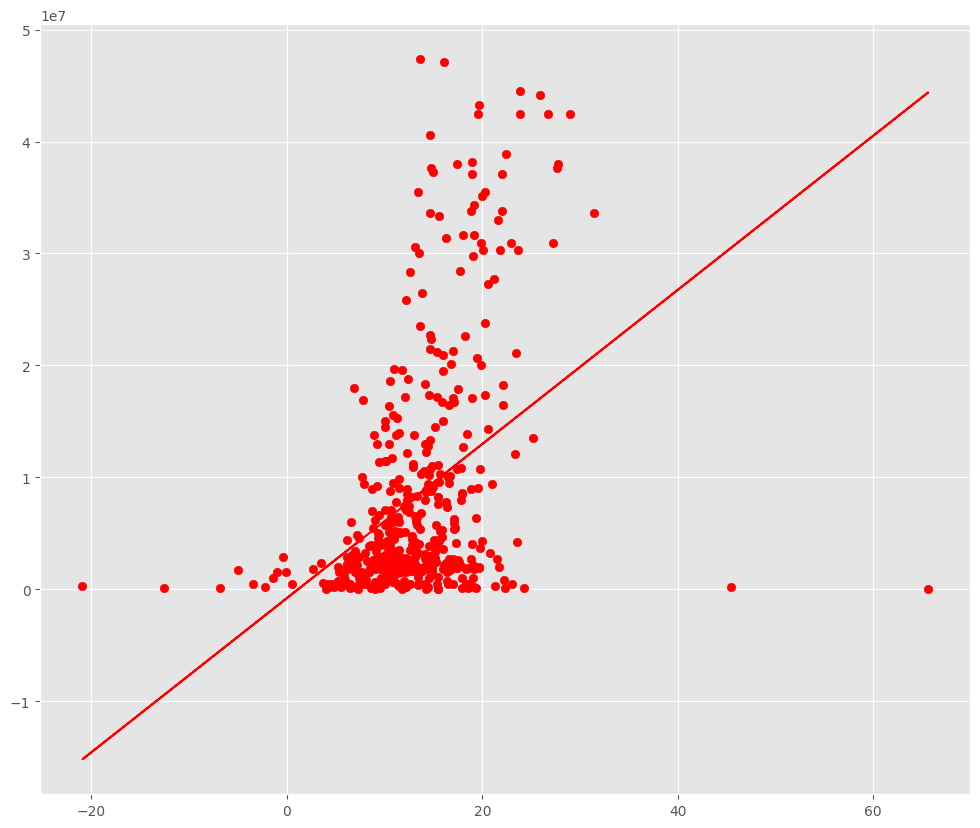

In [24]:
plt.figure(figsize = (12, 10))
plt.scatter(salaries_df['Player Efficiency Rating (ESPN Hollinger 2022-23)'], salaries_df['Salary'], color = 'red')
plt.plot(salaries_df['Player Efficiency Rating (ESPN Hollinger 2022-23)'], y_predict, 'r')
plt.show()

In [25]:
# intercept value
print('Intercept :', lr.intercept_)

# slope value
print('Slope :', lr.coef_)

Intercept : -795178.2941373829
Slope : [688471.82291672]


In [ ]:
plt.figure(figsize = (12, 10))
x_ax = range(len(salaries_df['Player Efficiency Rating (ESPN Hollinger 2022-23)']))
plt.plot(x_ax, salaries_df['Salary'], label = 'original')
plt.plot(x_ax, y_predict, label = 'predicted')
plt.title("PER and Predicted Salaries")
plt.legend()
plt.show()

In [28]:
from pandas import DataFrame
future_salaries = {'Player Efficiency Rating (ESPN Hollinger 2022-23)': [7.8, 9.3, 9.9, 10.3, 12.5, 12.7, 14.2, 14.7, 15.0, 18.0, 20.1, 20.6, 20.8, 21.7, 22.08, 22.5, 25.6, 25.9, 28.4, 30.75, 32.73, 34.5, 37.2]}
pred_df = DataFrame(future_salaries, columns = ['Player Efficiency Rating (ESPN Hollinger 2022-23)'])
pred_df

,Player Efficiency Rating (ESPN Hollinger 2022-23)
0,7.80
1,9.30
2,9.90
3,10.30
4,12.50
5,12.70
6,14.20
7,14.70
8,15.00
9,18.00


In [29]:
future_salaries = lr.predict(pred_df)
future_salaries

array([ 4574901.92461301,  5607609.65898809,  6020692.75273812,
        6296081.4819048 ,  7810719.49232158,  7948413.85690492,
        8981121.59128   ,  9325357.50273836,  9531899.04961338,
       11597314.51836353, 13043105.34648863, 13387341.25794699,
       13525035.62253033, 14144660.26315538, 14406279.55586373,
       14695437.72148875, 16829700.37253058, 17036241.91940559,
       18757421.47669739, 20375330.26055167, 21738504.46992677,
       22957099.59648936, 24815973.5183645 ])

In [30]:
pred_df['Projected Salaries'] = future_salaries / 1000000
pred_df

,Player Efficiency Rating (ESPN Hollinger 2022-23),Projected Salaries
0,7.80,4.574902
1,9.30,5.607610
2,9.90,6.020693
3,10.30,6.296081
4,12.50,7.810719
5,12.70,7.948414
6,14.20,8.981122
7,14.70,9.325358
8,15.00,9.531899
9,18.00,11.597315


## Model Evaluation

In [34]:
# -------------------------
# Model Evaluation
# -------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip()

# Clean Salary column
df['Salary'] = (
    df['Salary']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df['Salary_Millions'] = df['Salary'] / 1_000_000

# Choose feature column
per_col = 'Player Efficiency Rating (ESPN Hollinger 2022-23)'

# Make sure PER is numeric
df[per_col] = pd.to_numeric(df[per_col], errors='coerce')

# Keep only rows with valid PER and Salary
model_df = df[[per_col, 'Salary_Millions']].dropna()

# X = player efficiency rating
X = model_df[[per_col]]

# y = salary in millions
y = model_df['Salary_Millions']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict test set
y_pred = lr.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-------------------------")
print(f"Mean Absolute Error: ${mae:.2f} million")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f} million")
print(f"R-squared Score: {r2:.3f}")

print()
print("Linear Regression Equation")
print("-------------------------")
print(f"Predicted Salary = {lr.coef_[0]:.2f}(PER) + {lr.intercept_:.2f}")

Model Evaluation Results
-------------------------
Mean Absolute Error: $7.60 million
Mean Squared Error: 97.29
Root Mean Squared Error: $9.86 million
R-squared Score: 0.267

Linear Regression Equation
-------------------------
Predicted Salary = 0.62(PER) + 0.19


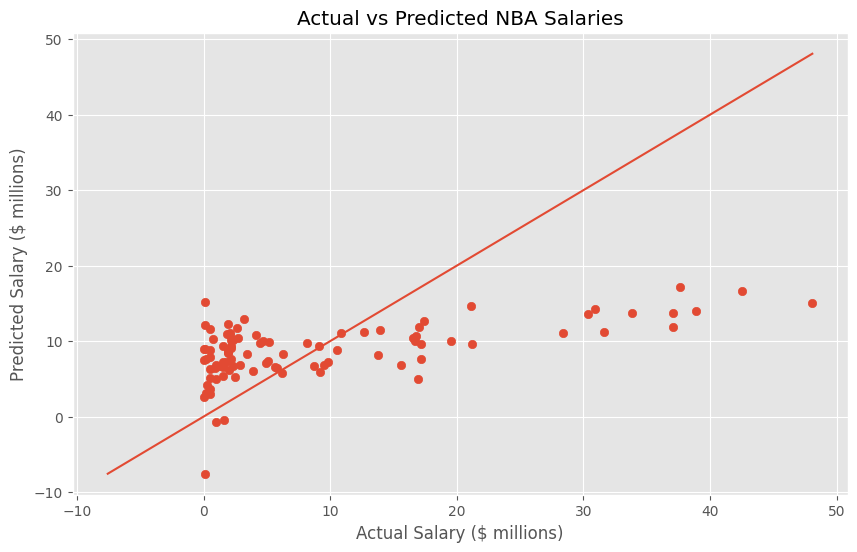

In [35]:
# -------------------------
# Actual vs Predicted Salary Visualization
# -------------------------

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)

# Perfect prediction line
min_salary = min(y_test.min(), y_pred.min())
max_salary = max(y_test.max(), y_pred.max())
plt.plot([min_salary, max_salary], [min_salary, max_salary])

plt.title("Actual vs Predicted NBA Salaries")
plt.xlabel("Actual Salary ($ millions)")
plt.ylabel("Predicted Salary ($ millions)")
plt.grid(True)
plt.show()

In [44]:
# -------------------------
# Key Findings with Player Names
# -------------------------

# Make sure Player, PER, and Salary are all in the modeling dataframe
model_df = df[['Player Name', per_col, 'Salary_Millions']].dropna()

# X = PER
X = model_df[[per_col]]

# y = Salary
y = model_df['Salary_Millions']

# Keep player names separately
players = model_df['Player Name']

# Train/test split, including players
X_train, X_test, y_train, y_test, players_train, players_test = train_test_split(
    X, y, players, test_size=0.20, random_state=42
)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Recalculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Create results dataframe
results_df = pd.DataFrame({
    'Player': players_test.values,
    per_col: X_test[per_col].values,
    'Actual Salary ($M)': y_test.values,
    'Predicted Salary ($M)': y_pred,
})

# Difference: positive = paid more than model predicted
results_df['Prediction Error ($M)'] = (
    results_df['Actual Salary ($M)'] - results_df['Predicted Salary ($M)']
)

# Round values
results_df['Actual Salary ($M)'] = results_df['Actual Salary ($M)'].round(2)
results_df['Predicted Salary ($M)'] = results_df['Predicted Salary ($M)'].round(2)
results_df['Prediction Error ($M)'] = results_df['Prediction Error ($M)'].round(2)
results_df[per_col] = results_df[per_col].round(2)

print("Top 10 Highest Actual Salaries in Test Set")
display(results_df.sort_values(by='Actual Salary ($M)', ascending=False).head(10))

print("Top 10 Most Overpaid Players Based on PER Model")
display(results_df.sort_values(by='Prediction Error ($M)', ascending=False).head(10))

print("Top 10 Most Underpaid Players Based on PER Model")
display(results_df.sort_values(by='Prediction Error ($M)', ascending=True).head(10))

print()
print("Key Findings Summary")
print("--------------------")
print(f"1. The model's R-squared value is {r2:.3f}, meaning PER explains about {r2 * 100:.1f}% of the variation in salary.")
print(f"2. The model's average error is about ${mae:.2f} million, based on Mean Absolute Error.")
print("3. A positive prediction error means the player earned more than the PER model predicted.")
print("4. A negative prediction error means the player earned less than the PER model predicted.")
print("5. PER is useful for measuring production, but salary is also affected by contracts, age, experience, team situation, free agency timing, and market value.")

Top 10 Highest Actual Salaries in Test Set


,Player,Player Efficiency Rating (ESPN Hollinger 2022-23),Actual Salary ($M),Predicted Salary ($M),Prediction Error ($M)
20,Stephen Curry,24.1,48.07,15.01,33.06
7,Damian Lillard,26.7,42.49,16.61,25.88
22,Kyrie Irving,22.4,38.92,13.97,24.95
70,Jimmy Butler,27.6,37.65,17.17,20.49
34,Trae Young,22.0,37.10,13.72,23.38
73,Zach LaVine,19.0,37.10,11.87,25.22
83,Devin Booker,22.0,33.83,13.72,20.11
28,Jamal Murray,18.0,31.65,11.26,20.39
2,Donovan Mitchell,22.9,30.91,14.27,16.64
35,De'Aaron Fox,21.8,30.35,13.60,16.75


Top 10 Most Overpaid Players Based on PER Model


,Player,Player Efficiency Rating (ESPN Hollinger 2022-23),Actual Salary ($M),Predicted Salary ($M),Prediction Error ($M)
20,Stephen Curry,24.1,48.07,15.01,33.06
7,Damian Lillard,26.7,42.49,16.61,25.88
73,Zach LaVine,19.0,37.10,11.87,25.22
22,Kyrie Irving,22.4,38.92,13.97,24.95
34,Trae Young,22.0,37.10,13.72,23.38
70,Jimmy Butler,27.6,37.65,17.17,20.49
28,Jamal Murray,18.0,31.65,11.26,20.39
83,Devin Booker,22.0,33.83,13.72,20.11
87,Chris Paul,17.7,28.40,11.07,17.33
35,De'Aaron Fox,21.8,30.35,13.60,16.75


Top 10 Most Underpaid Players Based on PER Model


,Player,Player Efficiency Rating (ESPN Hollinger 2022-23),Actual Salary ($M),Predicted Salary ($M),Prediction Error ($M)
62,Jordan Schakel,24.3,0.10,15.13,-15.04
80,Skylar Mays,19.4,0.12,12.12,-12.00
61,Micah Potter,18.6,0.51,11.63,-11.12
68,Thomas Bryant,19.7,1.97,12.30,-10.34
49,Andre Drummond,20.8,3.20,12.98,-9.78
82,Cody Zeller,16.4,0.74,10.27,-9.53
89,Charles Bassey,18.8,2.67,11.75,-9.08
26,Day'Ron Sharpe,17.8,2.11,11.14,-9.03
9,Moritz Wagner,17.4,1.88,10.89,-9.01
47,Jay Scrubb,14.2,0.05,8.92,-8.87



Key Findings Summary
--------------------
1. The model's R-squared value is 0.267, meaning PER explains about 26.7% of the variation in salary.
2. The model's average error is about $7.60 million, based on Mean Absolute Error.
3. A positive prediction error means the player earned more than the PER model predicted.
4. A negative prediction error means the player earned less than the PER model predicted.
5. PER is useful for measuring production, but salary is also affected by contracts, age, experience, team situation, free agency timing, and market value.


## Statistics Input

In [31]:
FGM = float(input("Enter FGM: "))
Steals = float(input("Enter Steals: "))
PTM_3 = float(input("Enter 3PM: "))
FTM = float(input("Enter FTM: "))
Blocks = float(input("Enter Blocks: "))
Offensive_Reb = float(input("Enter Offensive Rebounds: "))
Assists = float(input("Enter Assists: "))
Defensive_Reb = float(input("Enter Defensive Rebounds: "))
Fouls = float(input("Enter Fouls: "))
FT_Miss = float(input("Enter FT Missed: "))
FG_Miss = float(input("Enter FG Missed: "))
TO = float(input("Enter Turnovers: "))
Minutes = float(input("Enter Minutes: "))

PER_Calculation = ((FGM*85.901) + (Steals*53.897) + (PTM_3*51.757) + (FTM*46.845) + (Blocks*39.190) + (Offensive_Reb*39.190) + (Assists*34.677) + (Defensive_Reb*14.707) - (FT_Miss*20.091) - (FG_Miss*39.190) - (TO*53.897))*(1/Minutes) - 6

# PER and Salary Estimates

future_salaries = {'Player Efficiency Rating (ESPN Hollinger 2022-23)': [PER_Calculation]}
pred_df = DataFrame(future_salaries, columns = ['Player Efficiency Rating (ESPN Hollinger 2022-23)'])
pred_df

future_salaries = lr.predict(pred_df)
future_salaries

pred_df['Projected Salaries'] = future_salaries / 1000000
pred_df

KeyboardInterrupt: Interrupted by user

## Contract Creation

In [72]:
# Contract Creation

class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

years_on_team = int(input("Years under contract: "))
years_played = int(input("Years of experience: "))
if years_on_team >= 3 and years_played <= 6:
  contract_extend = str(input("FA Signing || Rookie Extension: "))
elif years_on_team >= 3 and (years_played >= 7 or years_played <= 8):
  contract_extend = str(input("FA Signing || Veteran Extension: "))
elif years_on_team < 3:
  contract_extend = str(input("FA Signing (Yes/No): "))
contract_option = str(input("Contract Options (Player, Team, None): "))
contract_clause = str(input("No Trade Clause (Yes/No): "))
player_name = str(input("Player Name: "))
year = int(input("Year: "))

print()

print(color.BOLD + f"{player_name}" + color.END)

if contract_extend == 'Yes' or years_on_team < 3:
  contract_years = int(input("Contract Years (1-4): "))
  contract_type = str(input("Contract Type (Flat (0%), Back (+5%), Front (-5%)): "))
  total_contract = (future_salaries / 1000000) * contract_years
  print(f'Total Contract: ${total_contract} mil / {contract_years} years')

  if (contract_type == 'Flat'):
    if (contract_years == 4):
      print(f"Cap Hits:  {year}/{year + 1}: ${total_contract / contract_years} mil" + f', {year + 1}/{year + 2:}: ${total_contract / contract_years} mil' + f',  ${year + 2}/{year + 3}: {total_contract / contract_years} mil' + f', ${year + 3}/{year + 4}: {total_contract / contract_years} mil')
    elif (contract_years == 3):
      print(f"Cap Hits:  {year}/{year + 1}: ${total_contract / contract_years} mil" + f', {year + 1}/{year + 2}: ${total_contract / contract_years} mil' + f',  {year + 2}/{year + 3}: ${total_contract / contract_years} mil')
    elif (contract_years == 2):
      print(f"Cap Hits:  {year}/{year + 1}: ${total_contract / contract_years} mil" + f', {year + 1}/{year + 2}: ${total_contract / contract_years} mil')
    elif (contract_years == 1):
      print(f"Cap Hits:  {year}/{year + 1}: ${total_contract / contract_years} mil")

  elif (contract_type == 'Back'):
    if (contract_years == 4):
      print(f"Cap Hits:  {year}/{year + 1}: ${((total_contract / contract_years) * .930232537146)} mil" + f', {year + 1}/{year + 2}: ${((total_contract / contract_years) * .930232537146) * .05 + ((total_contract / contract_years) * .930232537146)} mil' + f',  {year + 2}/{year + 3}: ${((total_contract / contract_years) * .930232537146) * .10 + ((total_contract / contract_years) * .930232537146)} mil' + f', {year + 3}/{year + 4}: ${((total_contract / contract_years) * .930232537146) * .15 + ((total_contract / contract_years) * .930232537146)} mil')
    elif (contract_years == 3):
      print(f"Cap Hits:  {year}/{year + 1}: ${((total_contract / contract_years) * .95238094463341)} mil" + f', {year + 1}/{year + 2}: ${((total_contract / contract_years) * .95238094463341) * .05 + ((total_contract / contract_years) * .95238094463341)} mil' + f',  {year + 2}/{year + 3}: ${((total_contract / contract_years) * .95238094463341) * .10 + ((total_contract / contract_years) * .95238094463341)} mil')
    elif (contract_years == 2):
      print(f"Cap Hits:  {year}/{year + 1}: ${((total_contract / contract_years) * .97560978097561)} mil" + f', {year + 1}/{year + 2}: ${((total_contract / contract_years) * .97560978097561) * .05 + ((total_contract / contract_years) * .97560978097561)} mil')
    elif (contract_years == 1):
      print(f"Cap Hits:  {year}/{year + 1}: ${((total_contract / contract_years))} mil")

  elif (contract_type == 'Front'):
    if (contract_years == 4):
      print(f"Cap Hits:  {year}/{year + 1}: ${((total_contract / contract_years) * .930232537146) * .15 + ((total_contract / contract_years) * .930232537146)} mil" + f', {year + 1}/{year + 2}: ${((total_contract / contract_years) * .930232537146) * .10 + ((total_contract / contract_years) * .930232537146)} mil' + f',  {year + 2}/{year + 3}: ${((total_contract / contract_years) * .930232537146) * .05 + ((total_contract / contract_years) * .930232537146)} mil' + f', {year + 3}/{year + 4}: ${((total_contract / contract_years) * .930232537146)} mil')
    elif (contract_years == 3):
      print(f"Cap Hits:  {year}/{year + 1}: ${((total_contract / contract_years) * .95238094463341) * .10 + ((total_contract / contract_years) * .95238094463341)} mil" + f', {year + 1}/{year + 2}: ${((total_contract / contract_years) * .95238094463341) * .05 + ((total_contract / contract_years) * .95238094463341)} mil' + f', {year + 2}/{year + 3}: ${((total_contract / contract_years) * .95238094463341)} mil')
    elif (contract_years == 2):
      print(f"Cap Hits:  {year}/{year + 1}: ${((total_contract / contract_years) * .97560978097561) * .05 + ((total_contract / contract_years) * .97560978097561)} mil" + f', {year + 1}/{year + 2}: ${((total_contract / contract_years) * .97560978097561)} mil')
    elif (contract_years == 1):
      print(f"Cap Hits:  {year}/{year + 1}: ${((total_contract / contract_years))} mil")


# Player Extensions/Bird Rights
if years_on_team >= 3:
  if contract_extend == 'Veteran Extension':
    extend_years = float(input("Veteran Extension (1-4.5) || Designated Veteran Extension [SUPERMAX] (4-5): "))
    if (extend_years == 5):
      league_cap = float(input("League Total Cap Space: "))
      extension_contract = (league_cap * .35) * extend_years
      print(f'League Cap: ${league_cap} mil')
      total_contract = ((league_cap * .35) * .16 + (league_cap * .35)) * extend_years
      print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
    if (extend_years == 4):
      league_cap = float(input("League Total Cap Space: "))
      extension_contract = (league_cap * .35) * extend_years
      print(f'League Cap: ${league_cap} mil')
      total_contract = ((league_cap * .35) * .16 + (league_cap * .35)) * extend_years
      print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
    total_contract = (future_salaries / 1000000) * extend_years
    if (extend_years == 5):
        print(f"Cap Hits:  {year}/{year + 1}: ${(league_cap * .35)} mil" + f', {year + 1}/{year + 2}: ${(league_cap * .35) * .08 + (league_cap * .35)} mil' + f',  {year + 2}/{year + 3}: ${(league_cap * .35) * .16 + (league_cap * .35)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .35) * .24 + (league_cap * .35)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .35) * .32 + (league_cap * .35)} mil')
    elif (extend_years == 4):
        print(f"Cap Hits:  {year}/{year + 1}: ${(league_cap * .35)} mil" + f', {year + 1}/{year + 2}: ${(league_cap * .35) * .08 + (league_cap * .35)} mil' + f',  {year + 2}/{year + 3}: ${(league_cap * .35) * .16 + (league_cap * .35)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .35) * .24 + (league_cap * .35)} mil')
    elif (extend_years == 4.5):
        print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
        print(f"Cap Hits:  {year}/{year + 1}: {((total_contract / 4) * .892857158879)}" + f', {year + 1}/{year + 2}: {((total_contract / 4) * .892857158879) * .08 + ((total_contract / 4) * .892857158879)}' + f',  {year + 2}/{year + 3}: {((total_contract / 4) * .892857158879) * .16 + ((total_contract / 4) * .892857158879)}' + f', {year + 3}/{year + 4}: {((total_contract / 4) * .892857158879) * .24 + ((total_contract / 4) * .892857158879)}')
    elif (extend_years == 3):
        print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
        print(f"Cap Hits:  {year}/{year + 1}: {((total_contract / extend_years) * .95238094463341)}" + f', {year + 1}/{year + 2}: {((total_contract / extend_years) * .95238094463341) * .08 + ((total_contract / extend_years) * .95238094463341)}' + f',  {year + 2}/{year + 3}: {((total_contract / extend_years) * .95238094463341) * .16 + ((total_contract / extend_years) * .95238094463341)}')
    elif (extend_years == 2):
        print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
        print(f"Cap Hits:  {year}/{year + 1}: {((total_contract / extend_years) * .97560978097561)}" + f', {year + 1}/{year + 2}: {((total_contract / extend_years) * .97560978097561) * .08 + ((total_contract / extend_years) * .97560978097561)}')
    elif (extend_years == 1):
        print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
        print(f"Cap Hits:  {year}/{year + 1}: {((total_contract / extend_years))}")
  elif contract_extend == 'Rookie Extension':
    extend_years = int(input("Rookie Extension (1-4) || Designated Rookie Extension [SUPERMAX] (5): "))
    if (extend_years == 5):
      league_cap = float(input("League Total Cap Space: "))
      extension_contract = (league_cap * .25) * extend_years
      print(f'League Cap: ${league_cap} mil')
    total_contract = (future_salaries / 1000000) * extend_years
    if (extend_years == 5):
        all_nba = str(input("All NBA (Yes/No): "))
        if all_nba == 'Yes':
          all_nba_team = str(input("All NBA Team (1st, 2nd, 3rd): "))
          if all_nba_team == '1st':
            total_contract = ((league_cap * .30) * .16 + (league_cap * .30)) * extend_years
            print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
            print(f"Cap Hits:  {year}/{year + 1}: ${(league_cap * .30)} mil" + f', {year + 1}/{year + 2}: ${(league_cap * .30) * .08 + (league_cap * .30)} mil' + f',  {year + 2}/{year + 3}: ${(league_cap * .30) * .16 + (league_cap * .30)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .30) * .24 + (league_cap * .30)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .28) * .32 + (league_cap * .30)} mil')
          if all_nba_team == '2nd':
            total_contract = ((league_cap * .28) * .16 + (league_cap * .28)) * extend_years
            print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
            print(f"Cap Hits:  {year}/{year + 1}: ${(league_cap * .28)} mil" + f', {year + 1}/{year + 2}: ${(league_cap * .28) * .08 + (league_cap * .28)} mil' + f',  {year + 2}/{year + 3}: ${(league_cap * .28) * .16 + (league_cap * .28)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .28) * .24 + (league_cap * .28)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .28) * .32 + (league_cap * .28)} mil')
          if all_nba_team == '3rd':
            total_contract = ((league_cap * .26) * .16 + (league_cap * .26)) * extend_years
            print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
            print(f"Cap Hits:  {year}/{year + 1}: ${(league_cap * .26)} mil" + f', {year + 1}/{year + 2}: ${(league_cap * .26) * .08 + (league_cap * .26)} mil' + f',  {year + 2}/{year + 3}: ${(league_cap * .26) * .16 + (league_cap * .26)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .26) * .24 + (league_cap * .26)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .26) * .32 + (league_cap * .26)} mil')
        elif all_nba == 'No':
          total_contract = ((league_cap * .25) * .16 + (league_cap * .25)) * extend_years
          print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
          print(f"Cap Hits:  {year}/{year + 1}: ${(league_cap * .25)} mil" + f', {year + 1}/{year + 2}: ${(league_cap * .25) * .08 + (league_cap * .25)} mil' + f',  {year + 2}/{year + 3}: ${(league_cap * .25) * .16 + (league_cap * .25)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .25) * .24 + (league_cap * .25)} mil' + f', {year + 3}/{year + 4}: ${(league_cap * .25) * .32 + (league_cap * .25)} mil')
    elif (extend_years == 4):
        print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
        print(f"Cap Hits:  {year}/{year + 1}: ${((total_contract / extend_years) * .892857158879)} mil" + f', {year + 1}/{year + 2}: ${((total_contract / extend_years) * .892857158879) * .08 + ((total_contract / extend_years) * .892857158879)} mil' + f',  {year + 2}/{year + 3}: ${((total_contract / extend_years) * .892857158879) * .16 + ((total_contract / extend_years) * .892857158879)} mil' + f', {year + 3}/{year + 4}: ${((total_contract / extend_years) * .892857158879) * .24 + ((total_contract / extend_years) * .892857158879)} mil')
    elif (extend_years == 3):
        print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
        print(f"Cap Hits:  {year}/{year + 1}: {((total_contract / extend_years) * .95238094463341)}" + f', {year + 1}/{year + 2}: {((total_contract / extend_years) * .95238094463341) * .08 + ((total_contract / extend_years) * .95238094463341)}' + f',  {year + 2}/{year + 3}: {((total_contract / extend_years) * .95238094463341) * .16 + ((total_contract / extend_years) * .95238094463341)}')
    elif (extend_years == 2):
        print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
        print(f"Cap Hits:  {year}/{year + 1}: {((total_contract / extend_years) * .97560978097561)}" + f', {year + 1}/{year + 2}: {((total_contract / extend_years) * .97560978097561) * .08 + ((total_contract / extend_years) * .97560978097561)}')
    elif (extend_years == 1):
        print(f'Extension Contract: ${total_contract} mil / {extend_years} years')
        print(f"Cap Hits:  {year}/{year + 1}: {((total_contract / extend_years))}")


print(f'Contract Option: {contract_option}')
print(f'No Trade Clause: {contract_clause}')

Years under contract: 2
Years of experience: 8
FA Signing (Yes/No): Yes
Contract Options (Player, Team, None): None
No Trade Clause (Yes/No): No
Player Name: Jalen
Year: 2023

Jalen
Contract Years (1-4): 2
Contract Type (Flat (0%), Back (+5%), Front (-5%)): Back
Total Contract: $[26.79174369] mil / 2 years
Cap Hits:  2023/2024: $[13.0691436] mil, 2024/2025: $[13.72260078] mil
Contract Option: None
No Trade Clause: No


In [ ]:
CONCLUSION
